# ACTIVIDAD 3: BASELINE

**Equipo 61**

Alumnos:

Gustavo Adolfo Morales García A00828432

Alejandro Jesús Mondragón Jiménez A01795837

Sebastián Ezequiel Coronado Rivera A01212824



### Objetivo
Este tercer avance tiene como objetivo construir un modelo baseline que funcione como punto de referencia inicial para evaluar la viabilidad del problema de aprendizaje automático. En el contexto de este proyecto, se busca inferir propiedades físicas de galaxias a partir de imágenes astronómicas, utilizando como etiquetas las variables asociadas a cada objeto en el conjunto de datos, tales como `LogMass`, `log_SFR_Ha`, `log_age_mean_LW`, `log_ZH_mean_LW`, entre otras.

Este avance también permite definir las métricas de calidad del modelo, analizar si existe subajuste o sobreajuste, y establecer un desempeño mínimo esperado. De esta manera, el baseline no solo cumple una función técnica, sino también metodológica antes de invertir tiempo en arquitecturas más complejas.

---

# 1.- ¿Qué algoritmo se puede utilizar como baseline para predecir las variables objetivo?

El problema abordado en este proyecto consiste en inferir propiedades físicas de galaxias a partir de imágenes astronómicas.

Debido a que la entrada principal del modelo corresponde a imágenes, el problema puede clasificarse como una tarea de visión computacional aplicada a regresión supervisada. A diferencia de problemas tradicionales de machine learning sobre datos tabulares, las imágenes representan datos no estructurados y de alta dimensionalidad, donde las relaciones espaciales entre píxeles contienen información relevante sobre la morfología y características físicas de las galaxias.

Considerando la naturaleza del problema, se analizaron distintas alternativas de algoritmos que podrían utilizarse como baseline.

### Regresión lineal

Los modelos tradicionales de regresión, como Linear Regression, Ridge Regression y Lasso, representan alternativas simples e interpretables para problemas de regresión supervisada sobre datos tabulares.

Sin embargo, el problema abordado en este proyecto difiere considerablemente de este tipo de escenarios, ya que la entrada principal del modelo corresponde a imágenes astronómicas. Estas imágenes constituyen datos no estructurados y de alta dimensionalidad, donde las relaciones espaciales entre píxeles contienen información relevante sobre la morfología y distribución de brillo de las galaxias.

Para que modelos lineales puedan trabajar con imágenes, sería necesario transformar cada imagen en un vector unidimensional. Este proceso provoca la pérdida de información espacial importante y dificulta la capacidad del modelo para identificar patrones visuales complejos asociados a las propiedades físicas de las galaxias.

Adicionalmente, las imágenes pueden contener miles o incluso millones de píxeles, lo que incrementa considerablemente la dimensionalidad del problema y limita la capacidad de los modelos lineales para capturar relaciones no lineales entre los datos de entrada y las variables objetivo.

Por estas razones, aunque los modelos tradicionales de regresión pueden utilizarse como referencia teórica inicial, no representan la alternativa más adecuada para el problema planteado en este proyecto.

### Redes Neuronales Convolucionales (CNNs)

Las Redes Neuronales Convolucionales (CNNs) representan una de las arquitecturas más utilizadas en problemas modernos de visión computacional debido a su capacidad para aprender automáticamente representaciones espaciales jerárquicas a partir de imágenes. A diferencia de los modelos tradicionales de machine learning, las CNNs preservan la estructura bidimensional de las imágenes mediante operaciones de convolución, permitiendo capturar patrones locales relevantes sin perder las relaciones espaciales entre píxeles.

De acuerdo con Géron (2022), las CNNs explotan características fundamentales de los datos visuales, como la conectividad local y el uso compartido de pesos (shared weights), reduciendo significativamente el número de parámetros necesarios en comparación con redes totalmente conectadas. Esto permite construir modelos capaces de identificar patrones visuales complejos de manera más eficiente y con mejor capacidad de generalización.

En el contexto astronómico, estas características resultan especialmente relevantes debido a que muchas propiedades físicas de las galaxias se encuentran relacionadas con patrones morfológicos observables en las imágenes, tales como distribución de brillo, concentración lumínica, estructuras espirales y formas galácticas. Las CNNs permiten aprender automáticamente dichas representaciones sin necesidad de realizar ingeniería manual de características, lo que las convierte en una alternativa adecuada para tareas de inferencia física basadas en imágenes astronómicas.

Las CNNs han demostrado resultados sobresalientes en múltiples aplicaciones de análisis astronómico y visión computacional, siendo uno de los enfoques predominantes para el procesamiento de imágenes de alta dimensionalidad.

Adicionalmente, el conjunto de datos disponible contiene aproximadamente diez mil imágenes astronómicas asociadas a distintas propiedades físicas, lo cual representa un volumen suficiente para explorar arquitecturas CNN relativamente sencillas como baseline inicial, manteniendo un balance razonable entre capacidad de aprendizaje y costo computacional.

Por estas razones, **las CNNs representan una alternativa adecuada para construir el baseline inicial de este proyecto y evaluar la viabilidad de inferir propiedades físicas de galaxias a partir de imágenes astronómicas.**


### Transfer Learning

El transfer learning consiste en reutilizar modelos previamente entrenados sobre grandes conjuntos de imágenes para aprovechar las características visuales que ya fueron aprendidas durante el entrenamiento inicial. Posteriormente, dichas arquitecturas pueden adaptarse al problema específico mediante el reemplazo y ajuste de las capas finales del modelo.

Debido a que el objetivo principal de esta etapa consiste en construir un baseline inicial y comprender el comportamiento básico del problema, se considera más apropiado comenzar con una arquitectura CNN relativamente sencilla antes de incrementar la complejidad del modelo mediante técnicas más avanzadas como transfer learning.

Dependiendo de los resultados obtenidos por el baseline inicial, técnicas de transfer learning y métodos adicionales de preprocesamiento de imágenes podrían explorarse en etapas posteriores del proyecto con el objetivo de mejorar el desempeño del modelo.

### Algoritmo seleccionado para el baseline

Considerando la naturaleza no estructurada de los datos, la importancia de preservar relaciones espaciales y el objetivo de construir un baseline inicial con complejidad controlada, se seleccionó una arquitectura CNN sencilla como punto de partida para este proyecto. Este enfoque permitirá evaluar la viabilidad inicial del problema antes de explorar arquitecturas más complejas basadas en transfer learning u otras técnicas avanzadas de visión computacional.

---

# 2.- ¿Se puede determinar la importancia de las características para el modelo generado?

En los avances anteriores se realizó un proceso de análisis de datos e ingeniería de características sobre las variables físicas asociadas a las galaxias. Este análisis permitió identificar valores redundantes, correlaciones y posibles relaciones relevantes entre variables objetivo, contribuyendo a la construcción de un conjunto de datos consistente y mejor estructurado para el entrenamiento del modelo.

Sin embargo, en el baseline propuesto para este avance, las imágenes astronómicas constituyen la entrada principal del modelo. Debido a ello, las características visuales relevantes no serán definidas manualmente, sino aprendidas automáticamente por la CNN mediante las capas convolucionales.



---


# 3. Construcción del dataset para el baseline

Antes de entrenar el modelo baseline, es necesario construir un conjunto de datos supervisado que relacione cada imagen astronómica con su variable objetivo. Para ello, se utiliza el identificador `name` como relación entre los datos tabulares y los archivos de imagen.

In [23]:
# Importación de librerías necesarias
from pathlib import Path
import pandas as pd  # Manipulación y análisis de datos
import numpy as np  # Operaciones numéricas y arrays
import matplotlib.pyplot as plt  # Visualización básica
import seaborn as sns  # Visualización estadística avanzada
from scipy import stats  # Funciones estadísticas
from scipy.stats import skew, kurtosis  # Métricas de distribución
import warnings  # Manejo de advertencias
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Configuración de estilos y opciones
warnings.filterwarnings('ignore')  # Ignorar advertencias para limpieza visual
sns.set_style('whitegrid')  # Estilo de gráficas con cuadrícula blanca
plt.rcParams['figure.figsize'] = (12, 6)  # Tamaño por defecto de figuras
plt.rcParams['font.size'] = 10  # Tamaño de fuente
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.precision', 4)  # Precisión decimal en display

In [24]:
#Leer archivo con datos originales
df = pd.read_csv("inferencia.csv")

#Copia de dataset
df_clean = df.copy()

#REEMPLAZAR PLACEHOLDERS POR NaN
placeholder_map = {
    "C": [-999],
    "A": [-999],
    "S": [-999, -102.97, -118.68],
    "nsa_sersic_mass": [-9999],
    "nsa_sersic_ba": [-9999],
    "nsa_sersic_n": [-9999]
}

for col, values in placeholder_map.items():
    df_clean[col] = df_clean[col].replace(values, np.nan)

#DEFINICIÓN DE VARIABLES 
# Variables con asimetría fuerte o potencialmente problemáticas
skewed_cols = [
    "nsa_sersic_mass",
    "PETRO_TH90",
    "modelMag_r",
    "C",
    "A",
    "S"
]

# Variables que ya están bastante estabilizadas o en log
normal_cols = [
    "LogMass",
    "nsa_sersic_ba",
    "nsa_sersic_n",
    "log_age_mean_LW",
    "log_ZH_mean_LW",
    "log_SFR_ssp",
    "log_SFR_Ha",
    "vel_sigma_Re"
]

# Coordenadas
coordinate_cols = [
    "objra",
    "objdec"
]

#Orden original de las columnas
final_columns = [
    "objra",
    "objdec",
    "C",
    "A",
    "S",
    "nsa_sersic_mass",
    "LogMass",
    "nsa_sersic_ba",
    "nsa_sersic_n",
    "PETRO_TH90",
    "log_age_mean_LW",
    "log_ZH_mean_LW",
    "log_SFR_ssp",
    "log_SFR_Ha",
    "vel_sigma_Re",
    "modelMag_r"
]

# Filtrar solo columnas existentes
skewed_cols = [c for c in skewed_cols if c in df_clean.columns]
normal_cols = [c for c in normal_cols if c in df_clean.columns]
coordinate_cols = [c for c in coordinate_cols if c in df_clean.columns]

#### Pipelines

Aunque el modelo baseline utilizará imágenes como entrada principal, se conserva este pipeline de preprocesamiento sobre la metadata para mantener identificadores consistentes, corregir valores faltantes o placeholders, y preparar las variables objetivo asociadas a cada galaxia.

In [25]:
# Para variables sesgadas: imputación + Yeo-Johnson + escalado
skewed_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("yeojohnson", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", StandardScaler())
])

# Para variables ya estables: imputación + escalado
normal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Para coordenadas: imputación + escalado
coordinate_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# COLUMN TRANSFORMER
preprocessor = ColumnTransformer([
    ("skewed_vars", skewed_pipeline, skewed_cols),
    ("normal_vars", normal_pipeline, normal_cols),
    ("coordinates", coordinate_pipeline, coordinate_cols)
], remainder="drop")

# 6. AJUSTAR Y TRANSFORMAR
X_transformed = preprocessor.fit_transform(df_clean)

transformer_columns = skewed_cols + normal_cols + coordinate_cols

df_transformed_numeric = pd.DataFrame(
    X_transformed,
    columns=transformer_columns,
    index=df_clean.index
)

# Reordenar columnas al formato deseado
df_transformed_numeric = df_transformed_numeric[final_columns]

# Conservar columna name como identificador de cada galaxia
df_transformed = pd.concat(
    [
        df_clean[["name"]],
        df_transformed_numeric
    ],
    axis=1
)

print("Shape original:", df_clean.shape)
print("Shape transformado:", df_transformed.shape)
df_transformed.head()

Shape original: (10126, 17)
Shape transformado: (10126, 17)


,name,objra,objdec,C,A,S,nsa_sersic_mass,LogMass,nsa_sersic_ba,nsa_sersic_n,PETRO_TH90,log_age_mean_LW,log_ZH_mean_LW,log_SFR_ssp,log_SFR_Ha,vel_sigma_Re,modelMag_r
0,manga-10001-12701,-0.6523,1.6126,-1.3471,-0.0074,-0.0309,-0.9490,-0.9403,-1.2084,-1.2748,-0.9719,-1.1521,-1.3084,0.8322,0.6072,2.0522,0.8076
1,manga-10001-12702,-0.6482,1.6060,-0.6744,-0.3508,-0.2956,-0.6325,-0.6049,-0.4241,-0.9179,0.1545,-1.0850,-0.7010,0.5290,0.1930,2.0572,1.0683
2,manga-10001-12703,-0.6176,1.5844,-0.0944,-0.2080,0.1655,-0.0753,-0.0354,-1.7963,-0.5420,-0.0049,-0.7376,-0.1556,0.7577,0.7587,0.6348,0.1766
3,manga-10001-12704,-0.6442,1.6170,0.1224,0.0694,0.7020,-0.7591,-0.7380,-2.0492,-1.2099,1.4307,-0.7461,-0.7883,-0.0408,0.3075,0.7127,-0.8335
4,manga-10001-12705,-0.6080,1.6044,-0.6729,-0.1478,-0.1510,-0.1074,-0.0674,-0.5909,-1.0158,-0.3170,-1.1710,-1.2657,1.0966,1.0637,1.9645,0.1993


### CNN con variable objetivo LogMass

In [26]:
target_col = "LogMass"

df_logmass = df_transformed[["name", target_col]].copy()

# Eliminar registros sin target
df_logmass = df_logmass.dropna(subset=[target_col])

print("Shape dataset LogMass:", df_logmass.shape)
df_logmass.head()

Shape dataset LogMass: (10126, 2)


,name,LogMass
0,manga-10001-12701,-0.9403
1,manga-10001-12702,-0.6049
2,manga-10001-12703,-0.0354
3,manga-10001-12704,-0.7380
4,manga-10001-12705,-0.0674


In [27]:
image_dir = Path(r"/Users/gustavomorales/Desktop/ITESM_MNA/Proyecto integrador/Imagenes")  # ajustar según carpeta real

df_logmass["image_path"] = df_logmass["name"].apply(
    lambda x: image_dir / f"{x}.jpg"
)

df_logmass["image_exists"] = df_logmass["image_path"].apply(lambda p: p.exists())

print("Total registros:", len(df_logmass))
print("Imágenes encontradas:", df_logmass["image_exists"].sum())
print("Imágenes faltantes:", (~df_logmass["image_exists"]).sum())

df_logmass = df_logmass[df_logmass["image_exists"]].copy()

df_logmass = df_logmass[
    ["name", target_col, "image_path"]
].copy()

df_logmass.head()

Total registros: 10126
Imágenes encontradas: 10126
Imágenes faltantes: 0


,name,LogMass,image_path
0,manga-10001-12701,-0.9403,/Users/gustavomorales/Desktop/ITESM_MNA/Proyec...
1,manga-10001-12702,-0.6049,/Users/gustavomorales/Desktop/ITESM_MNA/Proyec...
2,manga-10001-12703,-0.0354,/Users/gustavomorales/Desktop/ITESM_MNA/Proyec...
3,manga-10001-12704,-0.7380,/Users/gustavomorales/Desktop/ITESM_MNA/Proyec...
4,manga-10001-12705,-0.0674,/Users/gustavomorales/Desktop/ITESM_MNA/Proyec...


In [28]:
# 3. TRAIN / VALIDATION / TEST SPLIT

train_df, temp_df = train_test_split(
    df_logmass,
    test_size=0.30,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (7088, 3)
Validation: (1519, 3)
Test: (1519, 3)


In [29]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

def load_image_regression(image_path, target):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, target


def create_dataset(dataframe, shuffle=True):
    image_paths = dataframe["image_path"].astype(str).values
    targets = dataframe[target_col].astype("float32").values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, targets))
    dataset = dataset.map(load_image_regression, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=42)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)
test_ds = create_dataset(test_df, shuffle=False)

In [30]:
from tensorflow.keras import layers, models

# DATA AUGMENTATION

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1)
])

model_logmass = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="linear")
])

model_logmass.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_logmass.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_logmass = model_logmass.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - loss: 0.6348 - mae: 0.6337 - val_loss: 0.7193 - val_mae: 0.6909
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - loss: 0.3989 - mae: 0.4893 - val_loss: 0.6682 - val_mae: 0.6697
Epoch 3/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - loss: 0.3730 - mae: 0.4691 - val_loss: 0.3319 - val_mae: 0.4347
Epoch 4/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - loss: 0.3507 - mae: 0.4539 - val_loss: 0.3033 - val_mae: 0.4154
Epoch 5/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - loss: 0.3298 - mae: 0.4348 - val_loss: 0.3238 - val_mae: 0.4298
Epoch 6/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - loss: 0.3349 - mae: 0.4365 - val_loss: 0.2825 - val_mae: 0.3908
Epoch 7/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - loss: 0.3147 - mae: 0.4269 - val_loss: 0.3731 - val_mae: 0.4648
Epoch 8/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - loss: 0.3119 - mae: 0.4252 - val_loss: 0.2754 - val_mae: 0.3845
Epoch 9/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 

In [32]:
test_loss, test_mae = model_logmass.evaluate(test_ds)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.2320 - mae: 0.3616
Test MSE: 0.2320183366537094
Test MAE: 0.3616253435611725


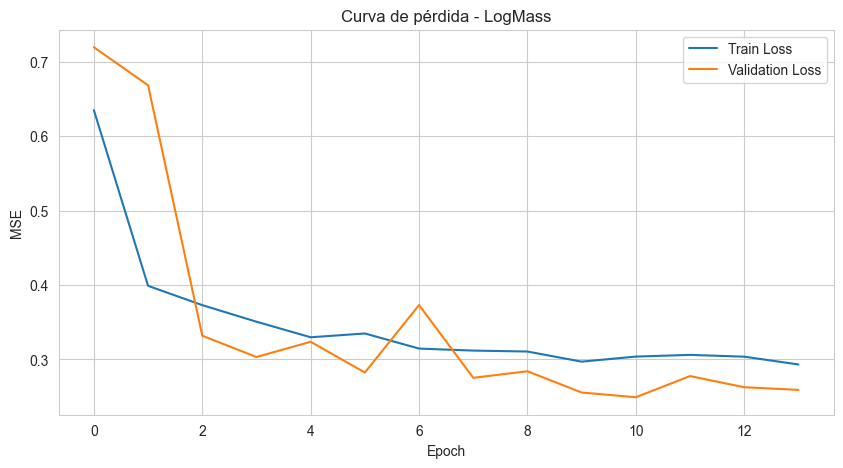

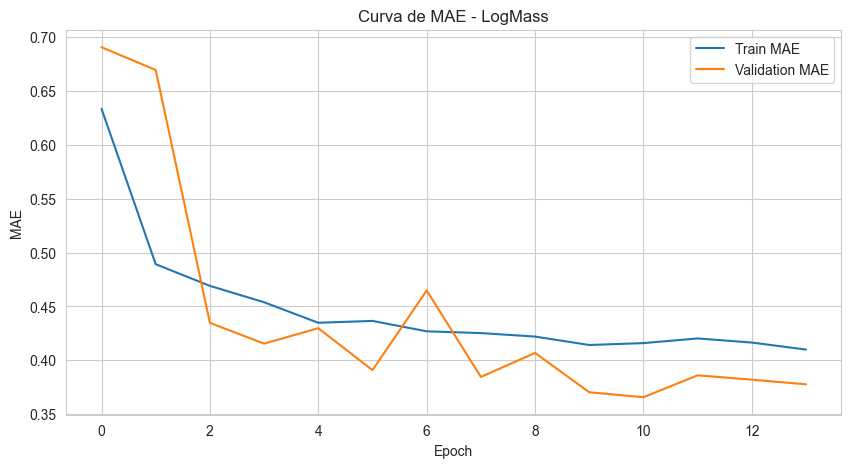

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(history_logmass.history["loss"], label="Train Loss")
plt.plot(history_logmass.history["val_loss"], label="Validation Loss")
plt.title("Curva de pérdida - LogMass")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_logmass.history["mae"], label="Train MAE")
plt.plot(history_logmass.history["val_mae"], label="Validation MAE")
plt.title("Curva de MAE - LogMass")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

In [34]:
print(df_transformed["LogMass"].describe())

count    1.0126e+04
mean    -1.6434e-15
std      1.0000e+00
min     -5.9192e+00
25%     -7.9491e-01
50%      4.3809e-02
75%      8.1244e-01
max      4.4971e+00
Name: LogMass, dtype: float64


In [35]:
# ==========================================================
# OBTENER PREDICCIONES DEL MODELO
# ==========================================================

y_true = []
y_pred = []

for images, labels in test_ds:
    
    predictions = model_logmass.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.flatten())

# Convertir a numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ==========================================================
# CALCULAR R²
# ==========================================================

r2 = r2_score(y_true, y_pred)

print(f"R² Score: {r2:.4f}")

R² Score: 0.7588


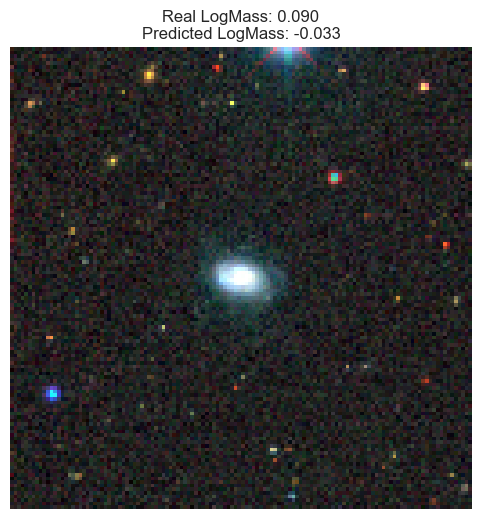

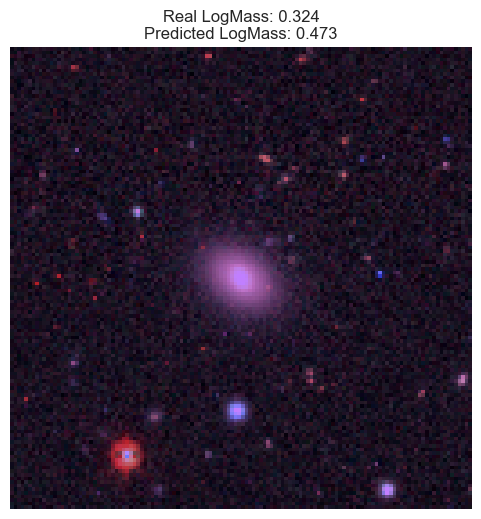

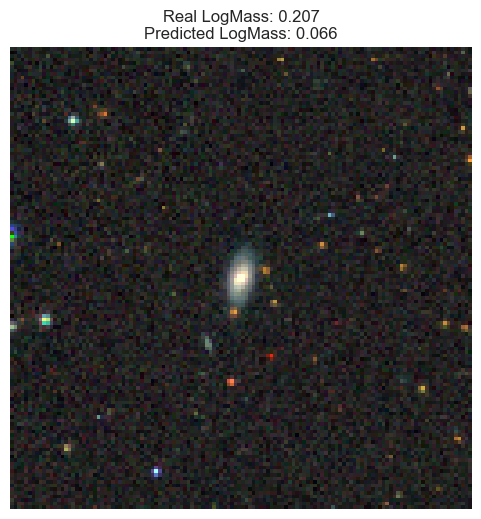

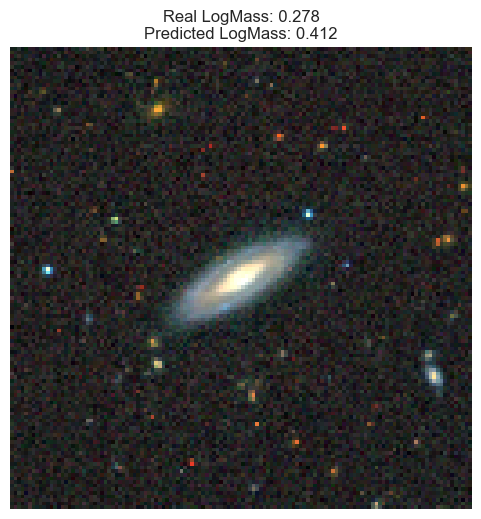

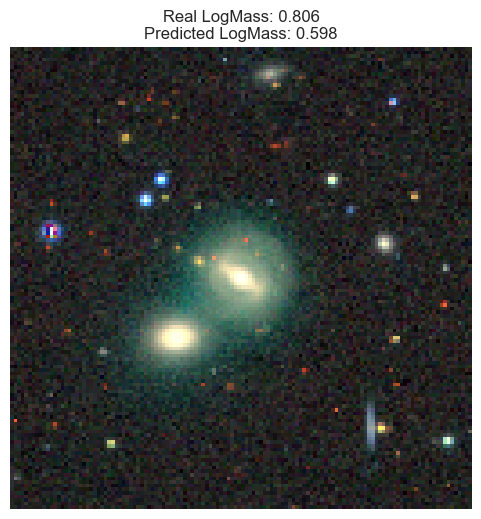

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

for i in range(5):
    # SELECCIONAR UNA MUESTRA ALEATORIA

    sample_row = test_df.sample(1).iloc[0]

    img_path = sample_row["image_path"]

    # Valor real
    real_logmass = sample_row[target_col]

    # CARGAR Y PREPROCESAR IMAGEN

    img = image.load_img(
        img_path,
        target_size=IMG_SIZE
    )

    img_array = image.img_to_array(img)

    # Normalización
    img_array = img_array / 255.0

    # Agregar dimensión batch
    img_input = np.expand_dims(img_array, axis=0)

    # PREDICCIÓN DEL MODELO

    pred_logmass = model_logmass.predict(
        img_input,
        verbose=0
    )[0][0]

    # VISUALIZACIÓN

    plt.figure(figsize=(6,6))

    plt.imshow(img_array)

    plt.title(
        f"Real LogMass: {real_logmass:.3f}\n"
        f"Predicted LogMass: {pred_logmass:.3f}"
    )

    plt.axis("off")

    plt.show()

# 4.- ¿El modelo está sub/sobreajustando los datos de entrenamiento?


# 5.- ¿Cuál es la métrica adecuada para este problema de negocio? 


# 6.- ¿Cuál debería ser el desempeño mínimo a obtener?
